<a href="https://colab.research.google.com/github/addo561/DDIM-With-CFG/blob/main/ddim_CFG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q lightning opendatasets diffusers tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 47.5 MB/s eta 0:00:00


In [2]:
import torch
import tqdm
import torchvision
import torch.nn as nn
import lightning as pl
import  opendatasets as od
import torchvision.transforms as tf
from torchvision.utils import make_grid
from torch.utils.data import DataLoader,random_split
import matplotlib.pyplot as plt
import  numpy as  np
from pathlib import Path
import glob
from PIL import Image
import logging

In [3]:
od.download('https://www.kaggle.com/datasets/andrewmvd/medical-mnist/data', data_dir='/content/')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: korlilarryaddo
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/medical-mnist


100%|██████████| 84.8M/84.8M [00:00<00:00, 1.57GB/s]

In [4]:
images = glob.glob('/content/medical-mnist/CXR/*')

In [5]:
image = Image.open(images[2])
img  =  np.array(image)
img.shape

(64, 64)

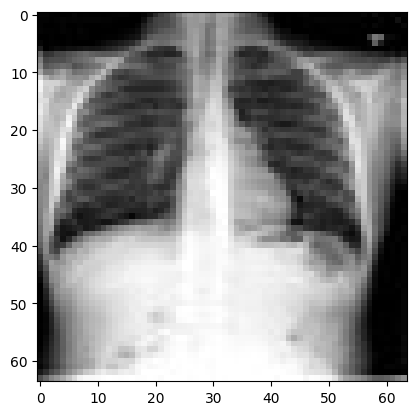

In [6]:
plt.imshow(img,cmap='gray')

In [7]:
tf_transform = tf.Compose([
    tf.transforms.ToTensor(),
    tf.transforms.Grayscale(1),
    tf.transforms.Normalize((0.5,), (0.5,))
])
ds = torchvision.datasets.ImageFolder('/content/medical-mnist/', transform=tf_transform)
train_size = int(0.8 * len(ds))
val_size = len(ds) - train_size
train, test = random_split(ds, [train_size, val_size])
train_dl = DataLoader(train,
                 batch_size=64,
                 shuffle=True,
                 drop_last=True,
                      )

val_dl = DataLoader(test,
                 batch_size=64,
                 shuffle=True,
                 drop_last=True)

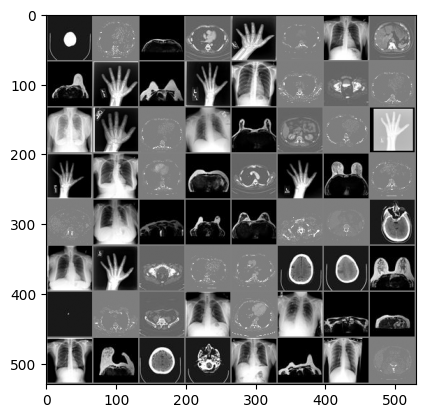

In [8]:
imgs,l  =  next(iter(train_dl))
grid  = make_grid(imgs)
plt.imshow(grid[0],cmap='gray')

In [9]:
len(train),len(test)

(47163, 11791)

In [10]:
#model unet
from diffusers import UNet2DModel
model = UNet2DModel(
    sample_size=64,  # the target image resolution
    in_channels=1,  # the number of input channels
    out_channels=1,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(64, 128, 128, 256),  # More channels -> more parameters
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",  # a regular ResNet upsampling block
    ),
)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [11]:
def cosine_scheduler(T:int, s:float=0.008):
  t = torch.linspace(0,T,T+1)
  f_t = torch.cos(((t/T + s)/ (1+s) ) * (torch.pi/2))**2
  alpha_bars = f_t/f_t[0]
  return alpha_bars


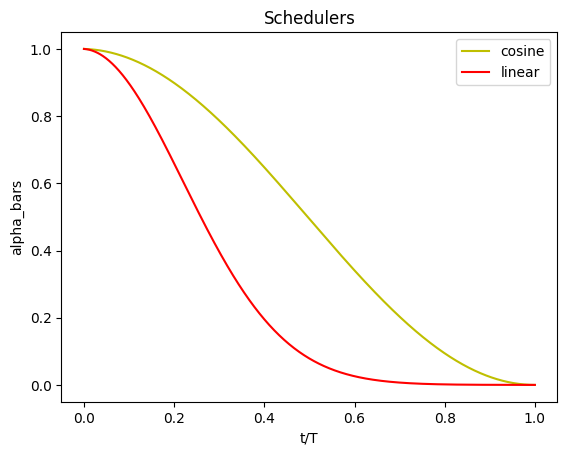

In [12]:
T = 1000
#cosine
t = np.linspace(0,T,T+1)
alpha_bars_cosine = cosine_scheduler(torch.tensor(1000)).numpy()
#linear
betas_linear = np.linspace(0.0001,0.02,T)
alpha_bars_linear  =  np.cumprod(1-betas_linear)
alpha_bars_linear  =  np.insert(alpha_bars_linear,0,1.)
#plot
cosine_x = t/T
linear_x = t/T
plt.title('Schedulers')
plt.plot(cosine_x,alpha_bars_cosine,c='y',label='cosine')
plt.plot(linear_x,alpha_bars_linear,c='r',label='linear')
plt.xlabel('t/T')
plt.ylabel('alpha_bars')
plt.legend()
plt.show()

In [13]:
len(betas_linear)

1000

In [14]:
class DDPM(nn.Module):
  def __init__(self,model,T):
    super().__init__()
    self.model = model
    self.register_buffer('alpha_bars',cosine_scheduler(T))
    alpha_prev = torch.cat([torch.ones(1),self.alpha_bars[:-1]])
    betas = torch.clip(1 - (self.alpha_bars / alpha_prev),0.0001,0.9999)
    self.register_buffer('betas',betas)
    self.register_buffer('alphas',1 - self.betas )
    self.register_buffer('sigma' ,self.betas **0.5)
    self.T = T

  def gather(self,tensor,t):
    return tensor[t].view(-1,1,1,1)

  def q_sample(self,x_0 : torch.Tensor,t,eps):
    alpha_bars  = self.gather(self.alpha_bars,t)
    mean = (alpha_bars**0.5)
    var =  (1 - alpha_bars)**0.5
    return  (mean * x_0 ) +  (var  * eps)
  #dont really need  this
  def p_sample(self,x_t: torch.Tensor,t):
    sigma = self.gather(self.sigma,t)
    alpha =  self.gather(self.alphas,t)
    mask  = (t>0).float().view(-1,1,1,1)
    z  = torch.randn_like(x_t) * mask
    scale1 = 1/alpha**0.5
    scale2 = (1-alpha) / (1-alpha)**0.5
    pred = self.model(x_t,t).sample
    mean = scale1  *  (x_t  -  (scale2  *  pred))
    var = sigma * z
    return mean  + var

  def loss(self,x_0: torch.Tensor):
    eps_0 =  torch.randn_like(x_0)
    t = torch.randint(0,self.T,(x_0.shape[0],),device=x_0.device)
    sample = self.q_sample(x_0,t,eps_0)
    pred = self.model(sample,t).sample
    loss  = nn.functional.mse_loss(eps_0,pred)
    return loss


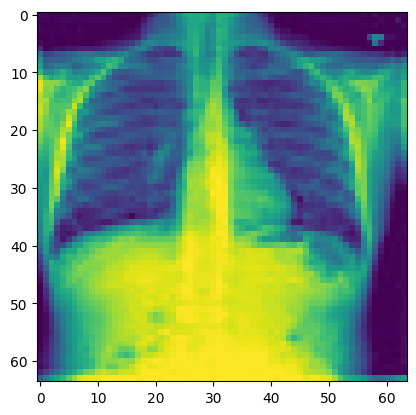

In [15]:
img = Image.open(images[2])
img  =  np.array(img)
plt.imshow(img)

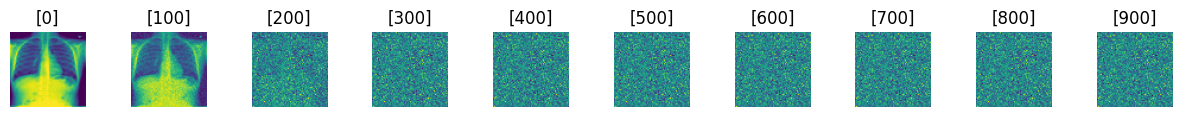

In [16]:
diffuse =  DDPM(model,1000)
#denoising  example
fig,ax = plt.subplots(1,10,figsize=(15,7))
i = 0
eps = torch.randn_like(torch.Tensor(img))
for t in range(1000):
  sample = diffuse.q_sample(torch.Tensor(img),t,eps).numpy()
  if t%100==0:
    ax[i].set_title(f'[{t}]')
    ax[i].imshow(sample.reshape(64,64))
    ax[i].axis('off')
    i+=1
  img = sample
plt.subplots_adjust(wspace=0.6, hspace=0.6)
plt.show()

Text(0.5, 1.0, 'Denoised example')

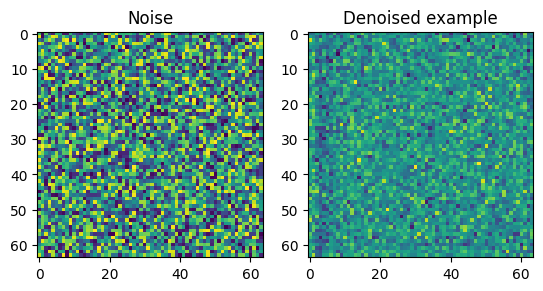

In [17]:
# Convert to float and normalize to [0, 1] ,  want to  get denoised image
noise  = np.random.rand(64,64)
input_tensor = torch.tensor(noise.reshape(1, 1, 64, 64)).float() / 255.0
sample = diffuse.p_sample(input_tensor, torch.tensor([700]))
fig,ax = plt.subplots(1,2)
ax[0].imshow(noise)
ax[0].set_title('Noise')
ax[1].imshow(sample.squeeze().detach().cpu().numpy())
ax[1].set_title('Denoised example')

In [18]:
input_tensor = torch.tensor(img.reshape(1, 1, 64, 64)).float() / 255.0
diffuse.loss(input_tensor)

tensor(1.2251, grad_fn=<MseLossBackward0>)

DDIM sampling
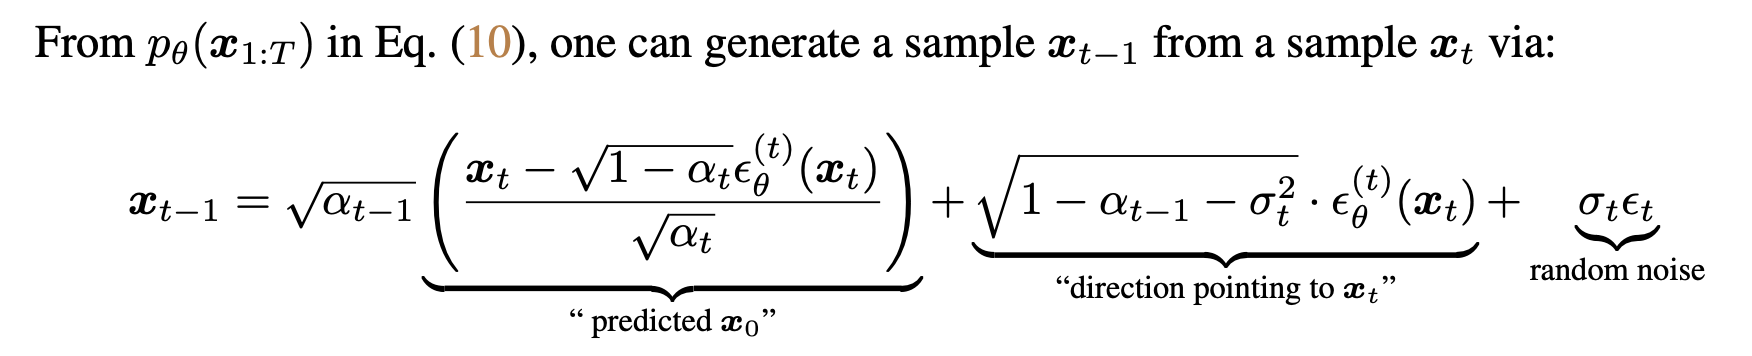

In [19]:
class DModel(pl.LightningModule):
  def __init__(self,unet,ddpm):
    super().__init__()
    self.unet = unet
    self.ddpm  = ddpm(self.unet,1000)
    self.T  = 1000

  def training_step(self,batch,batch_idx):
    x,_ = batch
    loss = self.ddpm.loss(x)
    self.log('val_loss',loss,sync_dist=True)
    return loss

  def configure_optimizers(self):
    optimizer = torch.optim.Adam(self.parameters(), lr=2e-4)
    return optimizer

  @torch.no_grad()
  def sample(self):
    """DDIM sampler
        1. Look at xt
        2. Predict the noise
        3. Estimate the clean image
        4. Re-noise it for the next timestep
        """
    # DDIM is designed to work with models trained using the DDPM objective (noise prediction)
    # without requiring retraining, allowing for faster sampling (e.g., 10-100 steps instead of 1000) while maintaining image quality
    # setting sigma to zero
    self.unet.eval()
    xt = torch.randn((2,1,64,64),device=self.device)
    for t_idx in tqdm.tqdm(reversed(range(0,self.T,10)),desc='Sampling',colour='blue'):
      t  = torch.full((xt.shape[0],),t_idx,device=self.device).long()
      t_prev  = torch.clamp(t-10,min=0)
      alpha_bars = self.ddpm.alpha_bars[t].reshape(-1,1,1,1)
      alpha_bars_prev  =  self.ddpm.alpha_bars[t_prev].reshape(-1,1,1,1)
      noise_pred = self.unet(xt,t).sample
      predict_x_0 =( xt  - (((1  -  alpha_bars)**0.5) * noise_pred)) /  (alpha_bars**0.5)
      predict_x_0 = predict_x_0.clamp(-1,1)
      pointing_xt  =   ((1 - alpha_bars_prev)**0.5) * noise_pred
      xt = (alpha_bars_prev **0.5) * predict_x_0 +  pointing_xt
    return xt

In [20]:
Path('ckpts/').mkdir(parents=True, exist_ok=True)

In [35]:
diffusion = DModel(model, DDPM)
trainer = pl.Trainer(
            max_epochs=25,
            log_every_n_steps=1,
            accelerator='gpu',
            precision="16-mixed",
)
trainer.fit(diffusion,
            train_dataloaders=train_dl,
            val_dataloaders=val_dl,
            ckpt_path='/content/epoch=24-step=18400.ckpt' #used checkpoint from model i trained on kaggle
            )

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.

┏━━━┳━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ unet │ UNet2DModel │ 18.5 M │ train │     0 │
│ 1 │ ddpm │ DDPM        │ 18.5 M │ train │     0 │
└───┴──────┴─────────────┴────────┴───────┴───────┘

Trainable params: 18.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 18.5 M                                                                                               
Total estimated model params size (MB): 74                                                                         
Modules in train mode: 332                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: Restored all states from the checkpoint at /content/epoch=24-step=18400.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restored all states from the checkpoint at /content/epoch=24-step=18400.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=25` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.


In [36]:
torch.cuda.empty_cache()

## Sampling with jump  of 10  steps (DDIM)

Sampling: 100it [00:53,  1.86it/s]


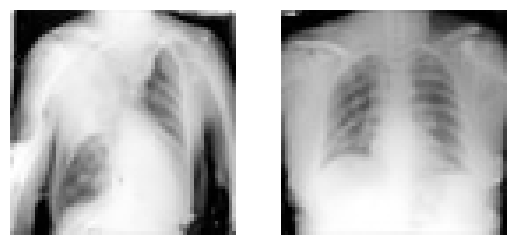

In [41]:
samples = diffusion.sample() # get image 10  steps  shorter, also accurate
samples =  (samples + 1)/2
samples = samples.clamp(0,1)
samples  =  samples.detach().cpu().numpy()
fig,ax = plt.subplots(1,2)
ax[0].imshow(samples[0].reshape(64,64),cmap='gray')
ax[1].imshow(samples[1].reshape(64,64),cmap='gray')
ax[0].axis('off')
ax[1].axis('off')
plt.show()

In [ ]:
torch.save(diffusion.unet.state_dict(),'Dmodel.pth')

In [ ]:
trainer.save_checkpoint('epoch=24-step=18400.ckpt')